In [ ]:
%load_ext autoreload
%autoreload 1
%aimport NLSE

import numpy as np

# Getting constants figured out

In [ ]:
beta2 = -4.20056799728266e-27 # s^2 m^-1

A_eff = 50e-12 # in m^2
n_2 = 3.2e-20 # m^2 W^-1
lambda_0 = 1.55e-6
gamma = 2 * np.pi * n_2 / (lambda_0 * A_eff)

N = 1
T_0 = 1e-12
FWHM = 1.76 * T_0
L_D = T_0 ** 2 / np.abs( beta2 )
P_0 = N ** 2 / ( L_D * gamma )
print(f'This simulation is happening for\n\tFWHM: {FWHM}s\n\tPower: {P_0} W\n\tN: {N}\n\tL_D: {L_D} m')

L_NL = 1 / ( gamma * P_0 )
assert np.isclose(L_D / L_NL, N ** 2), 'N is not self consistent!'

# 1D Case (linearly polarized)

In [ ]:
from NLSE import split_step

params = {
    'beta2': beta2,
    'gamma': gamma
}

t = np.linspace(-80e-12, 80e-12, 2048)
Z = np.linspace(0, 10*np.pi/2 * L_D, 2048)

A_0 = np.sqrt(P_0) / np.cosh(t / T_0)
print(f'This travels to:\n\tZ: {Z[-1]:.2f} m\n\tXi: {Z[-1] / L_D}')

A_out = split_step(A_0, t, Z, **params)

In [ ]:
A = np.zeros((5,2,A_0.size))
A[0,0] = A_0
print(np.vstack((A_0, A_0)).shape)

print(np.vstack((A_0, A_0))[0])

for ind, (A_x, A_y) in enumerate(A[:-1]):
    print(ind, A_x, A_y)

In [ ]:
import matplotlib.pyplot as plt

mid = A_out[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(A_out[::10,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

In [ ]:
plt.plot(t, np.abs(A_0), 'k')
plt.plot(t, np.abs(A_out[0]), 'r:')
plt.xlim(-5e-12,5e-12)

# 2D case

In [7]:
theta = np.pi / 3

tau = np.linspace(-80, 80, 2048)
Xi = np.linspace(0, 10 * np.pi, 2048)
# Z = np.linspace(0, 0.4, 10)
print(f'This travels to:\n\tZ: {Z[-1]:.2f} m\n\tXi: {Z[-1]}')

N = 0.7 + 0j

A0_X = N * np.cos(theta) / np.cosh(t)
A0_Y = N * np.sin(theta)/ np.cosh(t)

A = NLSE.split_step_2d_unitless(np.vstack((A0_X, A0_Y)), tau, Xi, delta=0.15)
A_X = A[:,0]
A_Y = A[:,1]
# A_X = split_step(A0_X, t, Z, **params)
# A_Y = split_step(A0_Y, t, Z, **params)

This travels to:
	Z: 31.42 m
	Xi: 31.41592653589793


In [11]:
print(np.abs(A_X[:,1024]))
print(np.abs(A_Y[:,1024]))

[0.35       0.60621778 0.         ... 0.         0.         0.        ]
[0.60621778 0.         0.         ... 0.         0.         0.        ]


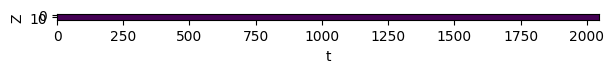

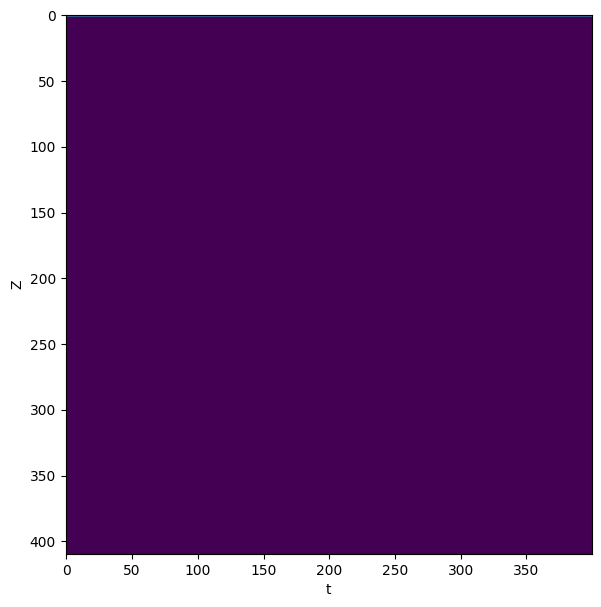

In [9]:
import matplotlib.pyplot as plt

mid = A_X[0].size // 2
plt.figure(figsize=(7,7))
# plt.imshow(np.abs(A_X[::5,mid-200:mid+200])**2)
plt.imshow(np.abs(A_X[:20])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

mid = A_Y[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(A_Y[::5,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

In [ ]:
# LCP = ( np.abs(A_X) ** 2 + np.abs(1j * A_Y) ** 2 ) / 2
LCP = ( A_X + 1j * A_Y ) / np.sqrt( 2 )
RCP = ( A_X - 1j * A_Y ) / np.sqrt( 2 )

mid = LCP[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(LCP[::5,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

plt.imshow(np.abs(RCP[::5,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()